# EDA — `features_dataset.csv` (Fase 2)

Carga la matriz con variables diferenciales, `sample_weight` (time decay) y mirroring. Ejecuta antes `python -m src.feature_engineering` desde la raíz del proyecto.

**Salidas de figuras:** al ejecutar las celdas con gráficos, las PNG se guardan en `reports/figures/01_eda/`.

In [21]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.notebook_figures import save_notebook_figure
from src.utils import PROCESSED_DIR

sns.set_theme(style="whitegrid")

df = pd.read_csv(PROCESSED_DIR / "features_dataset.csv", parse_dates=["date"])
TARGET = pd.Timestamp("2025-03-01")
LAMBDA_DECAY = 0.2408

## Validación rápida

In [22]:
print("shape:", df.shape)
print("result value_counts:")
print(df["result"].value_counts().sort_index())
df.filter(like="diff_").describe()

shape: (47232, 28)
result value_counts:
result
0    18035
1    11162
2    18035
Name: count, dtype: int64


,diff_elo,diff_fifa_rank,diff_top5_ratio,diff_win_ratio,diff_xg
count,47232.000000,47232.000000,47232.000000,47232.000000,47232.000000
mean,0.000000,0.000000,0.000000,0.000000,0.000000
std,250.024104,80.595421,0.285744,0.181936,0.980916
min,-1200.801524,-277.000000,-0.956522,-1.000000,-19.000000
25%,-157.171273,-44.000000,-0.118577,-0.120000,-0.522727
50%,0.000000,0.000000,-0.000000,-0.000000,-0.000000
75%,157.171273,44.000000,0.118577,0.120000,0.522727
max,1200.801524,277.000000,0.956522,1.000000,19.000000


## 1. Time decay — `sample_weight` vs tiempo

Partidos recientes pesan ~1.0; a ~5 años el peso teórico es ≈0.3 con $\lambda=0.2408$.

Figura guardada: C:\Users\echoe\Desktop\lab01\reports\figures\01_eda\01_time_decay_sample_weight.png


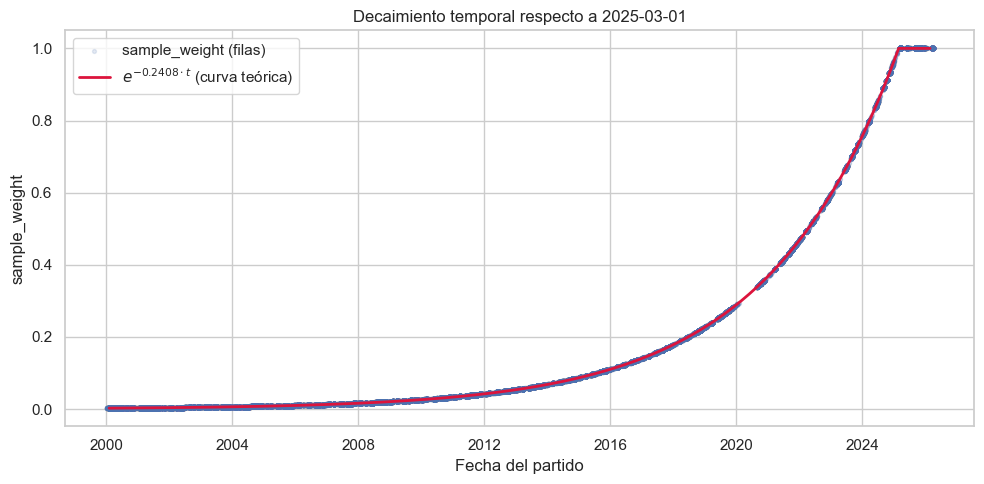

In [23]:
years_ago = (TARGET - df["date"]).dt.days / 365.25
theory = np.exp(-LAMBDA_DECAY * years_ago).clip(upper=1.0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["date"], df["sample_weight"], alpha=0.15, s=8, label="sample_weight (filas)")
grid = pd.date_range(df["date"].min(), df["date"].max(), freq="MS")
t_grid = (TARGET - grid).days / 365.25
w_grid = np.clip(np.exp(-LAMBDA_DECAY * t_grid), a_min=None, a_max=1.0)
ax.plot(grid, w_grid, color="crimson", lw=2, label=r"$e^{-0.2408 \cdot t}$ (curva teórica)")
ax.set_xlabel("Fecha del partido")
ax.set_ylabel("sample_weight")
ax.set_title("Decaimiento temporal respecto a 2025-03-01")
ax.legend()
plt.tight_layout()
path = save_notebook_figure(fig, notebook="01_eda", index=1, name="time_decay_sample_weight")
print("Figura guardada:", path.resolve())
plt.show()

## 2. Correlación — variables diferenciales vs `result`

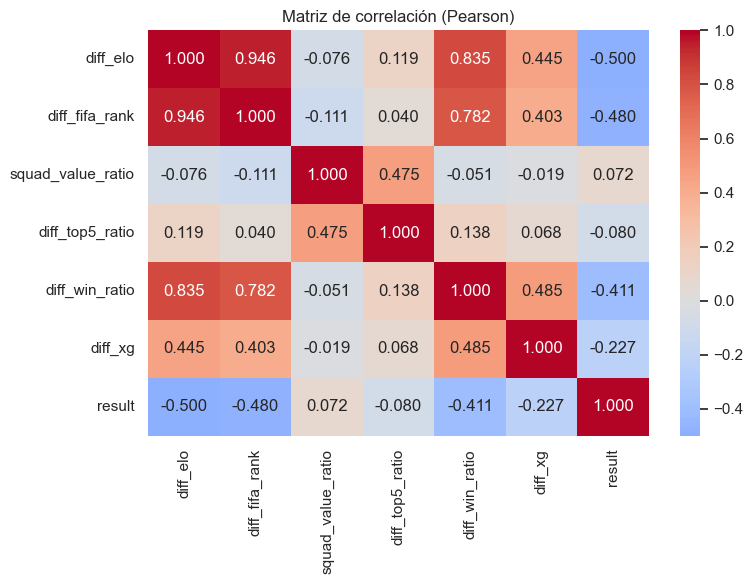

In [24]:
corr_cols = [
    "diff_elo",
    "diff_fifa_rank",
    "squad_value_ratio",
    "diff_top5_ratio",
    "diff_win_ratio",
    "diff_xg",
    "result",
]
cm = df[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".3f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
path = save_notebook_figure(fig, notebook="01_eda", index=2, name="correlation_heatmap_result")
print("Figura guardada:", path.resolve())
plt.show()

## Bonus — `tournament_weight` y `diff_elo` por resultado

Figura guardada: C:\Users\echoe\Desktop\lab01\reports\figures\01_eda\03_tournament_weight_diff_elo_by_result.png


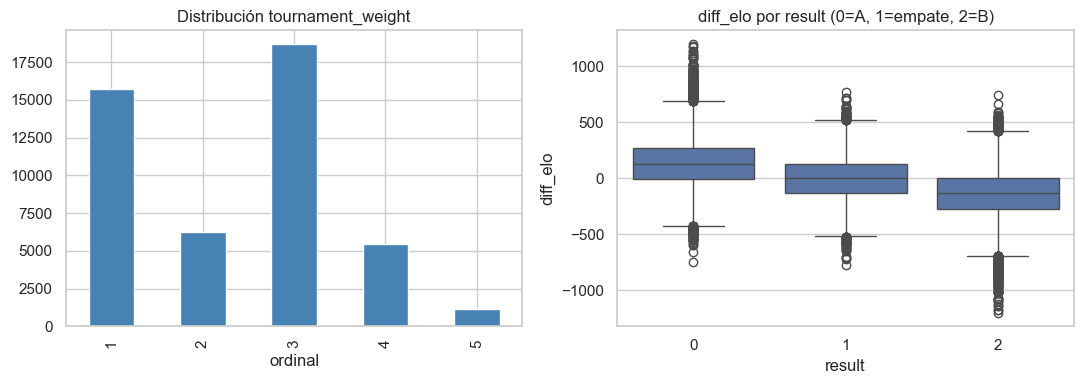

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["tournament_weight"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribución tournament_weight")
axes[0].set_xlabel("ordinal")
sns.boxplot(data=df, x="result", y="diff_elo", ax=axes[1])
axes[1].set_title("diff_elo por result (0=A, 1=empate, 2=B)")
plt.tight_layout()
path = save_notebook_figure(fig, notebook="01_eda", index=3, name="tournament_weight_diff_elo_by_result")
print("Figura guardada:", path.resolve())
plt.show()

## Siguiente paso

- [02_training.ipynb](02_training.ipynb) — entrenamiento y calibración sobre `features_dataset.csv`.
- [03_simulation.ipynb](03_simulation.ipynb) — Monte Carlo del Mundial 2026 con el modelo guardado.